# Data Preparation Assignment

## Student Name: Peterson Eduardo Sampaio Silva

## Module: Data Preparation

## Assignment: CA1

## Introduction

Project focuses on data preparation and analysis using a student dataset.

The main objective is to clean the data, explore patterns, and apply Principal Component Analysis to reduce dimensionality while preserving most of the information.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

The dataset is loaded using the pandas library. This part ensures that the data is available for further analysis and processing.

In [2]:
df = pd.read_csv("student_data.csv")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171.0,1,1,122.0,1,19,12.0,...,0,0.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254.0,1,1,160.0,1,1,3.0,...,0,6.0,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070.0,1,1,122.0,1,37,37.0,...,0,6.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773.0,1,1,122.0,1,38,37.0,...,0,6.0,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014.0,0,1,100.0,1,37,38.0,...,0,6.0,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Exploration

Next part we will understand the structure of the dataset. This includes checking the number of rows and columns, data types, and summary statistics.

In [3]:
df.shape

(4424, 37)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   object 
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4423 non-null   float64
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [5]:
df.describe()

,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4423.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4423.000000,4424.000000,...,4424.000000,4424.000000,4423.000000,4424.000000,4424.000000,4423.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,18.669078,1.727848,8856.458738,0.890823,4.577758,132.613314,1.873192,19.561935,22.271987,10.960895,...,0.137658,0.541817,6.231743,8.063291,4.435805,10.229941,0.150316,11.566139,1.228029,0.001969
std,17.484682,1.313793,2063.763479,0.311897,10.216592,13.188332,6.914514,15.603186,15.343244,26.418253,...,0.690880,1.918546,2.196038,3.947951,3.014764,5.211367,0.753774,2.663850,1.382711,2.269935
min,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,194.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


## Dataset Characterisation

The dataset contains 4424 observations (rows) and 37 attributes (columns), representing various demographic, academic, and socio-economic characteristics of students.

The dataset includes a mix of data types, including integer, float, and categorical (object) variables. This indicates that the dataset contains both numerical and categorical information, which is important for different types of analysis.

From the initial inspection using the `.info()` method, it is evident that some columns contain missing values. While most columns have 4424 non-null entries, a few columns have slightly fewer, indicating the presence of missing data that will need to be addressed during the data preparation stage.

The dataset also includes a target variable named "Target", which represents the outcome for each student. This variable contains three categories: dropout, enrolled, and graduate. This suggests that the dataset is suitable for a classification problem.

Overall, the dataset is relatively large and complex, with multiple features that may contribute to the outcome variable. The presence of missing values and mixed data types highlights the need for careful data cleaning and preprocessing before further analysis.

## Missing Values Analysis

Next part we will check for missing values. Identifying missing data is important to ensure data quality and decide how to handle incomplete records.

In [6]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            1
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            1
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   1
Displaced                                         0
Educational special needs                         0
Debtor                                            1
Tuition fees up to date                           1
Gender                                            0
Scholarship holder                                0
Age at enrol

## Data Cleaning

For next step we will show the missing values and invalid entries are handled to improve data quality. Some incorrect values will be identified and corrected, and rows with missing data will be removed.

In [7]:
df = df.dropna()

In [8]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [9]:
df.shape

(4415, 37)

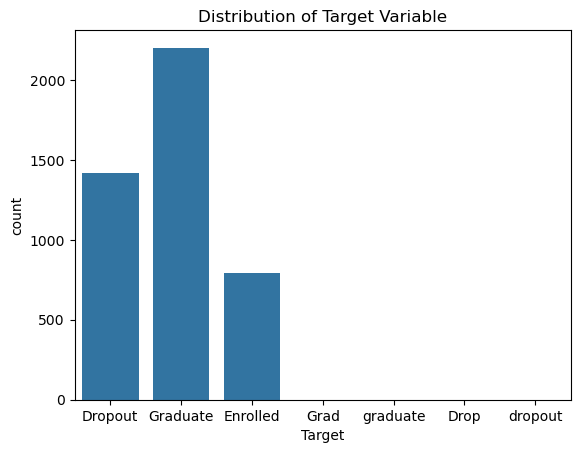

In [10]:
sns.countplot(x='Target', data=df)
plt.title('Distribution of Target Variable')
plt.show()

In [11]:
df['Target'] = df['Target'].str.lower()

In [12]:
df['Target'].value_counts()

Target
graduate    2202
dropout     1418
enrolled     793
grad           1
drop           1
Name: count, dtype: int64

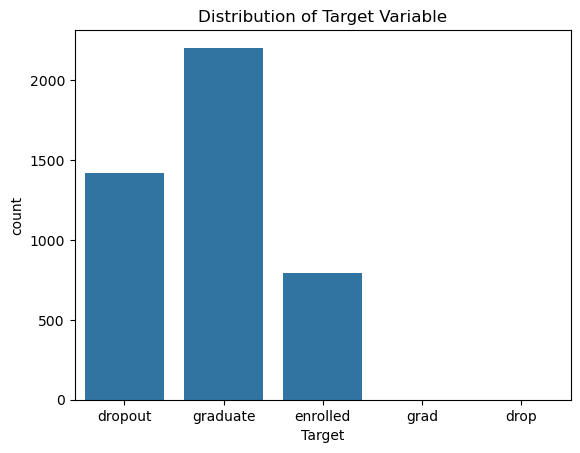

In [13]:
sns.countplot(x='Target', data=df)
plt.title('Distribution of Target Variable')
plt.show()

In [14]:
df['Target'] = df['Target'].str.lower()

df['Target'] = df['Target'].replace({
    'grad': 'graduate',
    'drop': 'dropout'
})

In [15]:
df['Target'].value_counts()

Target
graduate    2203
dropout     1419
enrolled     793
Name: count, dtype: int64

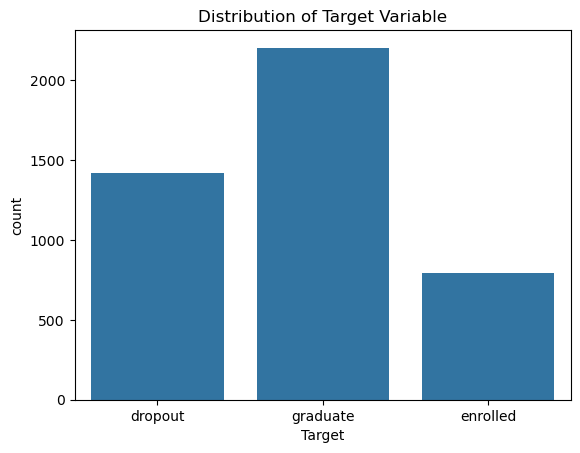

In [16]:
sns.countplot(x='Target', data=df)
plt.title('Distribution of Target Variable')
plt.show()

## Cleaning Target Variable

The target variable contained inconsistent values such as different cases and abbreviations. These were standardised to ensure consistent categories. Was removed some informations to make the graphic looks clean and organized.

## Data Distribution

Histograms were created to visualise the distribution of numerical variables. This can helps to understand how data is spread and identify skewness or unusual patterns.

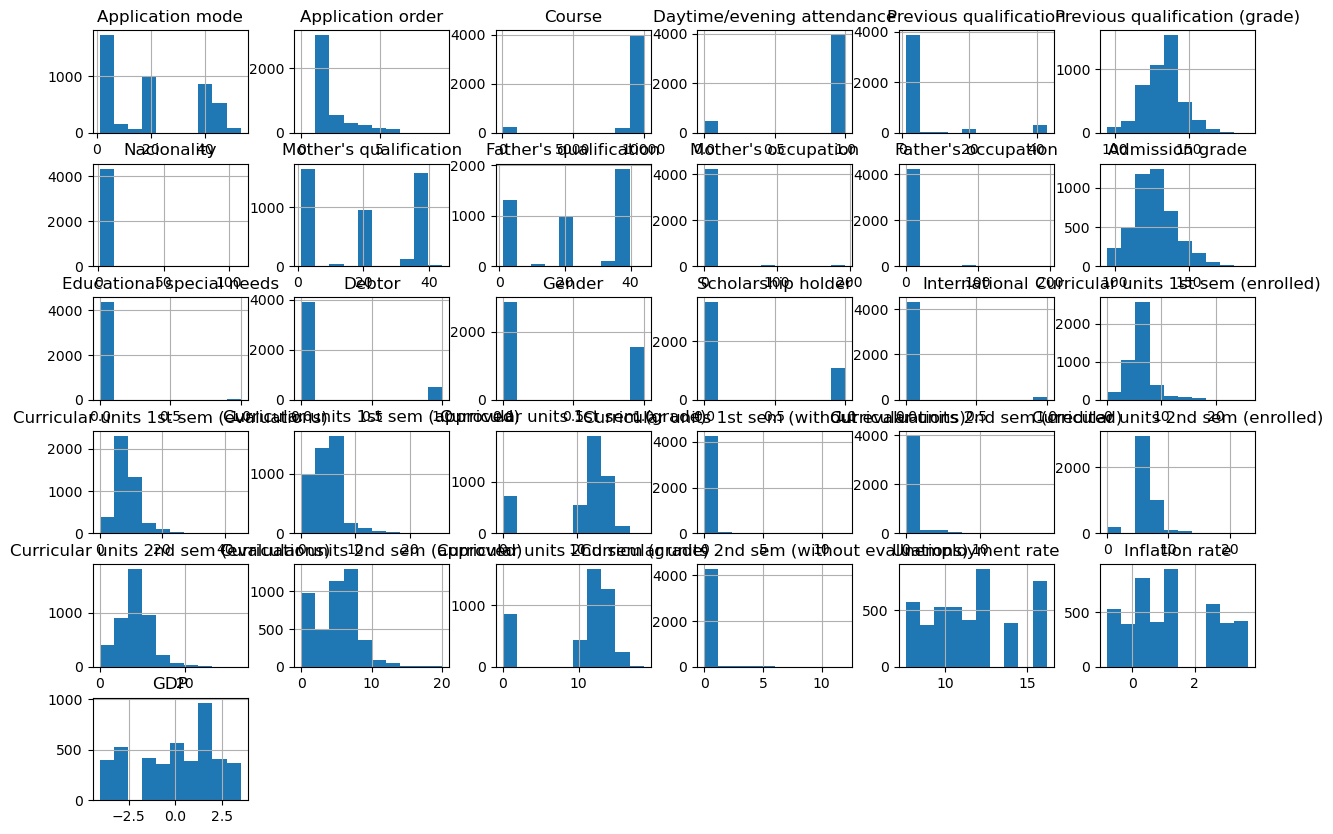

In [17]:
df.hist(figsize=(15,10))
plt.show()

## Outlier Detection

Boxplots were used to identify potential outliers in selected numerical variables. Outliers are extreme values that may influence analysis and model results.

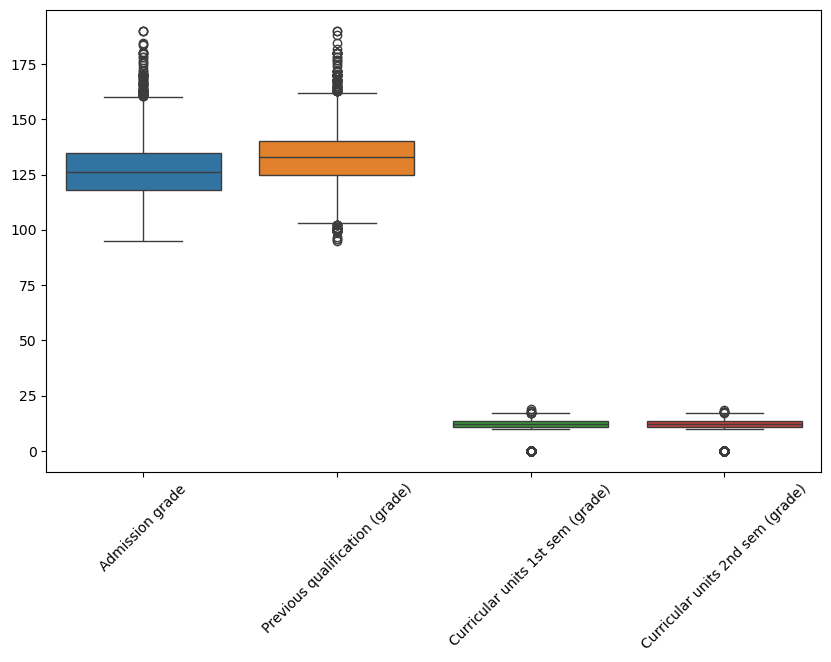

In [20]:
cols = [
    'Admission grade',
    'Previous qualification (grade)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]

plt.figure(figsize=(10,6))
sns.boxplot(data=df[cols])
plt.xticks(rotation=45)
plt.show()

In [22]:
df.select_dtypes(include='object').columns

Index(['Marital status', 'Displaced', 'Tuition fees up to date',
       'Age at enrollment', 'Curricular units 1st sem (credited)', 'Target'],
      dtype='object')

In [23]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(df[col].unique()[:10])


Column: Marital status
['1' '2' '4' '?' '3' '5' '6']

Column: Displaced
['1' '0']

Column: Tuition fees up to date
['1' '0' '?']

Column: Age at enrollment
['20' '19' '45' '50' '18' '22' '21' '34' '37' '43']

Column: Curricular units 1st sem (credited)
['0' '2' '3' '6' '7' '13' '4' '1' '5' '19']

Column: Target
['dropout' 'graduate' 'enrolled']


In [26]:
df['Tuition fees up to date'] = df['Tuition fees up to date'].replace([';', '?'], np.nan)

In [28]:
df['Tuition fees up to date'] = pd.to_numeric(df['Tuition fees up to date'], errors='coerce')

In [29]:
df = df.dropna()

In [31]:
cols_to_convert = [
    'Marital status',
    'Displaced',
    'Tuition fees up to date',
    'Age at enrollment',
    'Curricular units 1st sem (credited)'
]

for col in cols_to_convert:
    df.loc[:, col] = pd.to_numeric(df[col], errors='coerce')

In [32]:
df = df.dropna()

In [33]:
df.select_dtypes(include='object').columns

Index(['Target'], dtype='object')

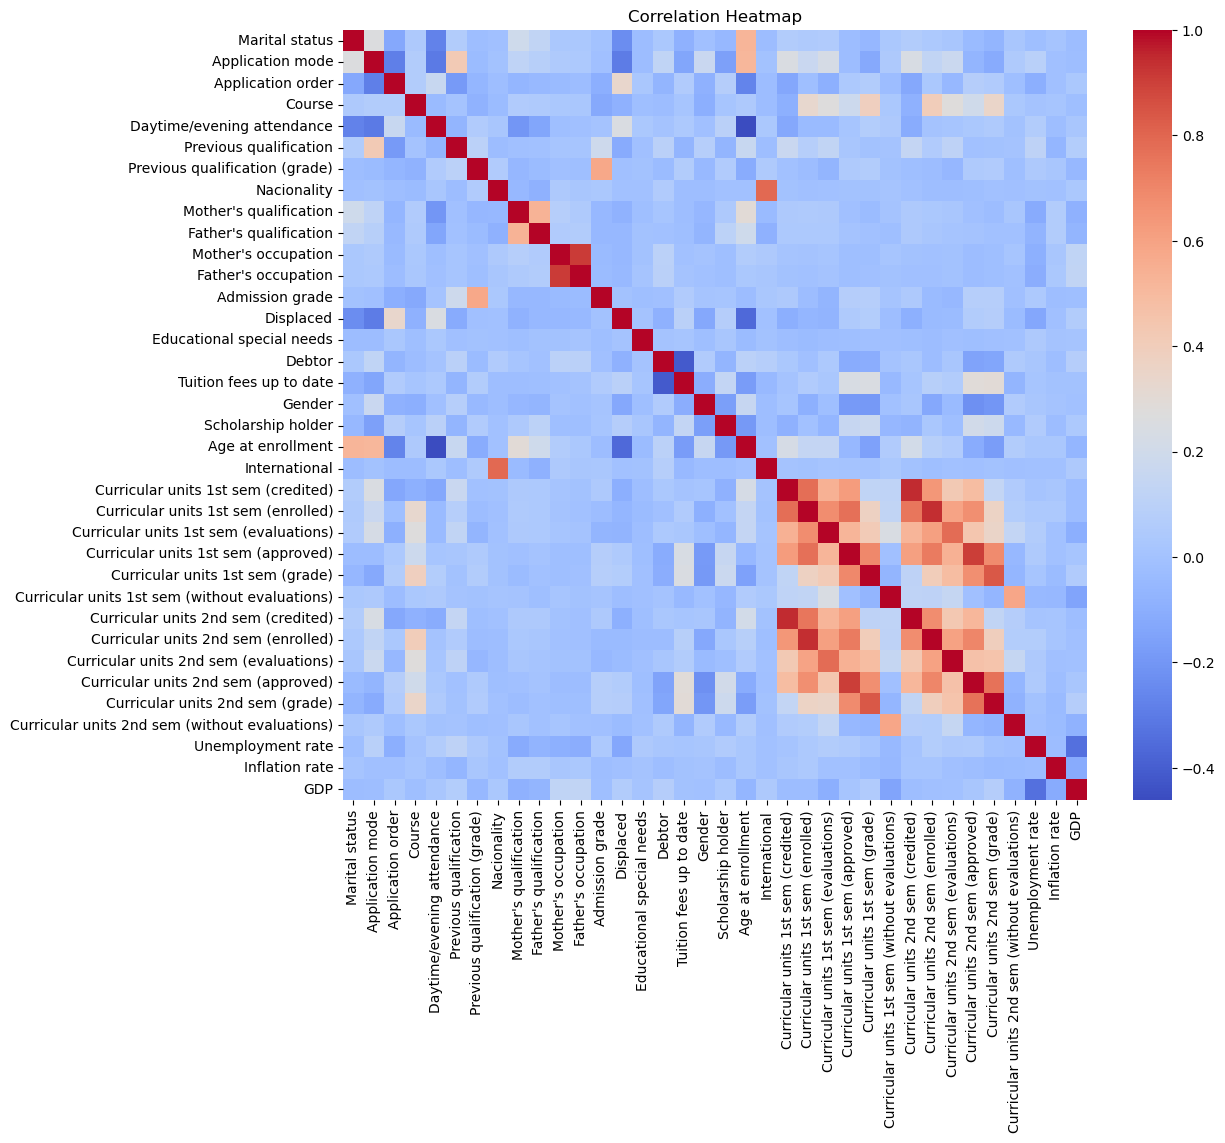

In [34]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [35]:
X = df.drop('Target', axis=1)
y = df['Target']

In [36]:
print(X.shape)
print(y.shape)

(4411, 36)
(4411,)


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
print(X_scaled.shape)

(4411, 36)


In [39]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [40]:
import numpy as np

explained_variance = np.cumsum(pca.explained_variance_ratio_)

print(explained_variance)

[0.17656287 0.27540868 0.33404394 0.38996225 0.44260004 0.48921385
 0.53343655 0.57616283 0.61207633 0.64646628 0.67672812 0.70484971
 0.73227029 0.758203   0.78243243 0.80500086 0.82698563 0.84725728
 0.86497177 0.8812845  0.89685377 0.91163962 0.92448552 0.9370884
 0.94857578 0.95925452 0.96810041 0.97475942 0.98056642 0.98586438
 0.99057124 0.99347424 0.9960163  0.99843362 0.9994196  1.        ]


In [41]:
n_components = np.argmax(explained_variance >= 0.995) + 1
print(n_components)

33


In [42]:
pca = PCA(n_components=33)
X_reduced = pca.fit_transform(X_scaled)

print(X_reduced.shape)

(4411, 33)


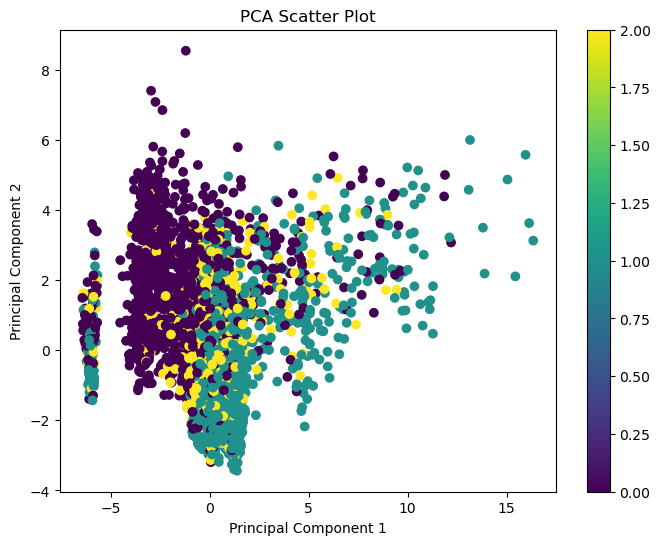

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=pd.factorize(y)[0])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Scatter Plot')
plt.colorbar()
plt.show()